In [ ]:
!pip -q install roboflow keras-unet-collection opencv-python scikit-learn

import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
!pip install roboflow
"""70/15/15 slpit   """
from roboflow import Roboflow
rf = Roboflow(api_key="OjD4gEstmxbK6KOUcSCW")
project = rf.workspace("b6509545").project("fruit-segmentation-6tafu")
version = project.version(1)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install -q roboflow
!pip install -q keras-unet-collection
!pip install -q pycocotools

In [ ]:
import os
import cv2
import json
import numpy as np

from pycocotools.coco import COCO

from tensorflow.keras.utils import Sequence
from tensorflow.keras.optimizers import Adam

import tensorflow as tf

from keras_unet_collection import models

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from pycocotools.coco import COCO

import segmentation_models_pytorch as smp

In [ ]:
dataset_path = dataset.location

train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir = os.path.join(dataset_path, "test")

In [ ]:
class FruitDataset(Dataset):

    def __init__(self,image_dir,annotation_file,image_size=256):

        self.image_dir=image_dir
        self.coco=COCO(annotation_file)

        self.ids=list(self.coco.imgs.keys())

        self.image_size=image_size

    def __len__(self):

        return len(self.ids)

    def __getitem__(self,index):

        image_id=self.ids[index]

        info=self.coco.loadImgs(image_id)[0]

        image_path=os.path.join(
            self.image_dir,
            info["file_name"]
        )

        image=cv2.imread(image_path)

        image=cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image=cv2.resize(
            image,
            (self.image_size,self.image_size)
        )

        image=image/255.0

        mask=np.zeros(
            (
                info["height"],
                info["width"]
            ),
            dtype=np.uint8
        )

        ann_ids=self.coco.getAnnIds(imgIds=image_id)

        anns=self.coco.loadAnns(ann_ids)

        for ann in anns:

            mask=np.maximum(
                mask,
                self.coco.annToMask(ann)
            )

        mask=cv2.resize(
            mask,
            (self.image_size,self.image_size),
            interpolation=cv2.INTER_NEAREST
        )

        image=torch.tensor(
            image.transpose(2,0,1),
            dtype=torch.float32
        )

        mask=torch.tensor(
            mask,
            dtype=torch.float32
        )

        mask=mask.unsqueeze(0)

        return image,mask

In [ ]:
train_dataset = FruitDataset(
    train_dir,
    os.path.join(train_dir,"_annotations.coco.json")
)

valid_dataset = FruitDataset(
    valid_dir,
    os.path.join(valid_dir,"_annotations.coco.json")
)

test_dataset = FruitDataset(
    test_dir,
    os.path.join(test_dir,"_annotations.coco.json")
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

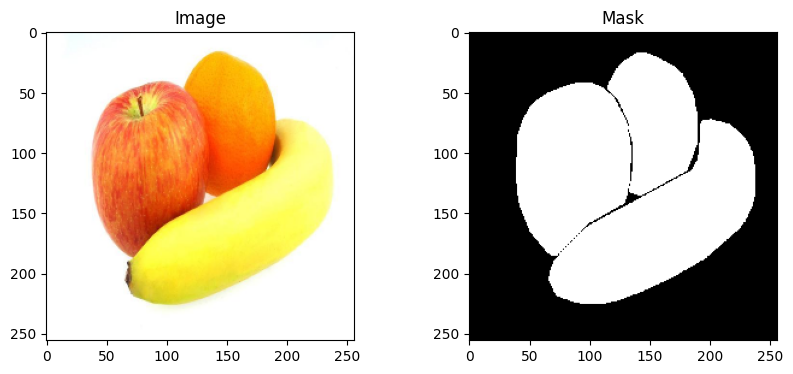

In [ ]:
image,mask=train_dataset[0]

plt.figure(figsize=(10,4))

plt.subplot(121)

plt.imshow(image.permute(1,2,0))

plt.title("Image")

plt.subplot(122)

plt.imshow(mask.squeeze(),cmap="gray")

plt.title("Mask")

plt.show()

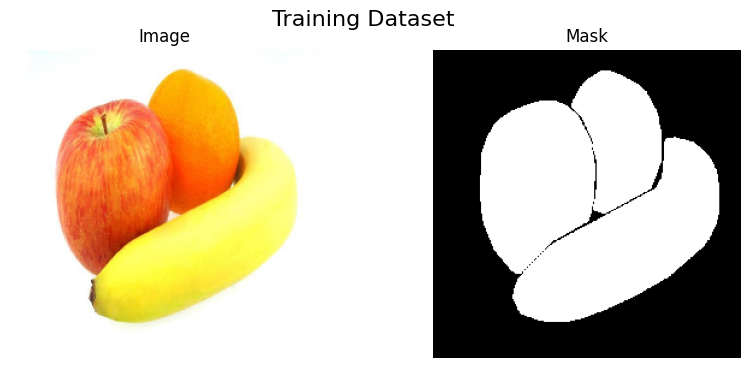

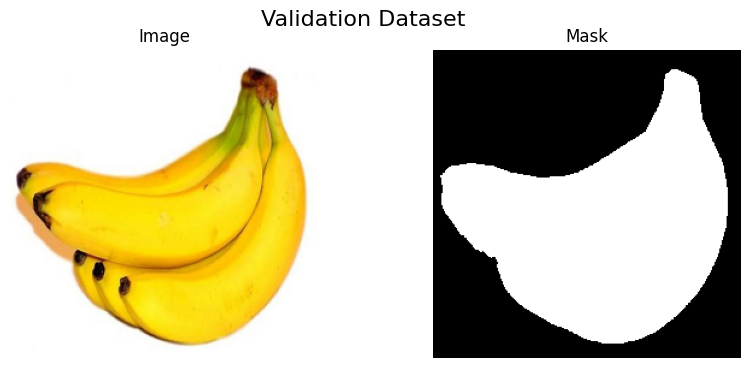

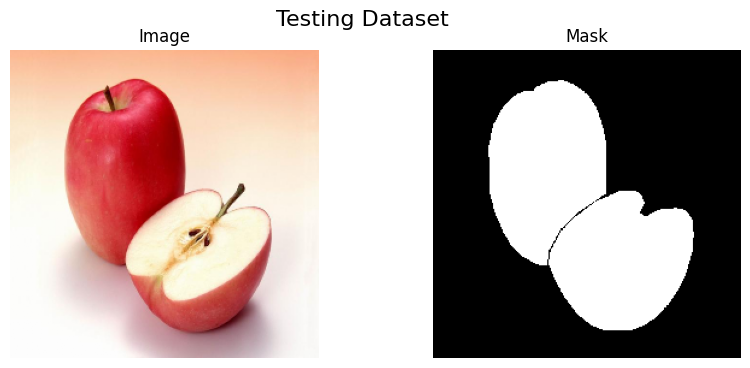

In [ ]:
import matplotlib.pyplot as plt

def visualize_dataset(dataset, title):

    image, mask = dataset[0]

    image = image.permute(1, 2, 0).numpy()
    mask = mask.squeeze().numpy()

    plt.figure(figsize=(10,4))

    plt.suptitle(title, fontsize=16)

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.show()


visualize_dataset(train_dataset, "Training Dataset")
visualize_dataset(valid_dataset, "Validation Dataset")
visualize_dataset(test_dataset, "Testing Dataset")

In [ ]:
import os

# Function to display dataset information
def dataset_info(dataset_name, image_dir):

    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif')

    images = [f for f in os.listdir(image_dir)
              if f.lower().endswith(image_extensions)]

    total_images = len(images)

    # One segmentation mask exists for every image
    total_masks = total_images

    print("="*45)
    print(f"{dataset_name} Dataset")
    print("="*45)
    print("Total Images :", total_images)
    print("Total Masks  :", total_masks)
    print()

dataset_info("Training", train_dir)
dataset_info("Validation", valid_dir)
dataset_info("Testing", test_dir)

Training Dataset
Total Images : 113
Total Masks  : 113

Validation Dataset
Total Images : 14
Total Masks  : 14

Testing Dataset
Total Images : 14
Total Masks  : 14



In [ ]:
train_images = len(train_dataset)
valid_images = len(valid_dataset)
test_images = len(test_dataset)

total_images = train_images + valid_images + test_images

print("Training Images   :", train_images)
print("Validation Images :", valid_images)
print("Testing Images    :", test_images)

print("-"*35)
print("Total Images      :", total_images)

Training Images   : 113
Validation Images : 14
Testing Images    : 14
-----------------------------------
Total Images      : 141


In [ ]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(valid_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print("-----------------------------------------")

print(f"Total Dataset Images : {len(train_dataset)+len(valid_dataset)+len(test_dataset)}")

DATASET SUMMARY
Training Images   : 113
Validation Images : 14
Testing Images    : 14
-----------------------------------------
Total Dataset Images : 141


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
model = smp.PSPNet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1

)

model = model.to(device)

In [ ]:
print(model)

PSPNet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
import torch.nn as nn

criterion = DiceLoss()

In [ ]:
class DiceLoss(nn.Module):

    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        smooth = 1

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2. * intersection + smooth) / (
            pred.sum() + target.sum() + smooth
        )

        return 1 - dice

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

In [ ]:
best_loss = float("inf")

patience = 5

counter = 0

num_epochs = 10

In [ ]:
best_loss = float("inf")
patience = 5
counter = 0
num_epochs = 20

for epoch in range(num_epochs):

    # -------------------- Training --------------------
    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------------------- Validation --------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in valid_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(valid_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_loss:

        best_loss = val_loss

        counter = 0

        torch.save(model.state_dict(), "pspnet_best.pth")

        print("Best model saved.")

    else:

        counter += 1

    # Early stopping
    if counter >= patience:

        print("Early stopping triggered.")

        break

Epoch [1/20]
Train Loss: 0.0548
Validation Loss: 0.0749
Best model saved.
Epoch [2/20]
Train Loss: 0.0516
Validation Loss: 0.0843
Epoch [3/20]
Train Loss: 0.0559
Validation Loss: 0.0961
Epoch [4/20]
Train Loss: 0.0449
Validation Loss: 0.0772
Epoch [5/20]
Train Loss: 0.0488
Validation Loss: 0.0767
Epoch [6/20]
Train Loss: 0.0400
Validation Loss: 0.0789
Early stopping triggered.


In [ ]:
model.load_state_dict(torch.load("pspnet_best.pth"))

model.eval()

PSPNet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
def iou_score(pred, mask):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()

    union = pred.sum() + mask.sum() - intersection

    return (intersection + 1e-6) / (union + 1e-6)

In [ ]:
def dice_score(pred, mask):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()

    return (2 * intersection + 1e-6) / (
        pred.sum() + mask.sum() + 1e-6
    )

In [ ]:
def pixel_accuracy(pred, mask):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    correct = (pred == mask).float().sum()

    total = torch.numel(pred)

    return correct / total

In [ ]:
iou = 0

dice = 0

acc = 0

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        masks = masks.to(device)

        outputs = model(images)

        iou += iou_score(outputs, masks)

        dice += dice_score(outputs, masks)

        acc += pixel_accuracy(outputs, masks)

print("Mean IoU :", (iou / len(test_loader)).item())

print("Mean Dice :", (dice / len(test_loader)).item())

print("Pixel Accuracy :", (acc / len(test_loader)).item())

Mean IoU : 0.8772175312042236
Mean Dice : 0.9343858957290649
Pixel Accuracy : 0.9559898376464844


In [ ]:
images, masks = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():

    predictions = torch.sigmoid(model(images))

predictions = (predictions > 0.5).float().cpu()

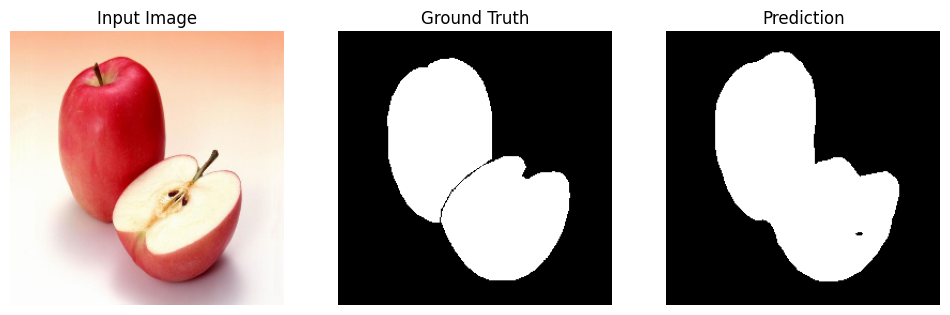

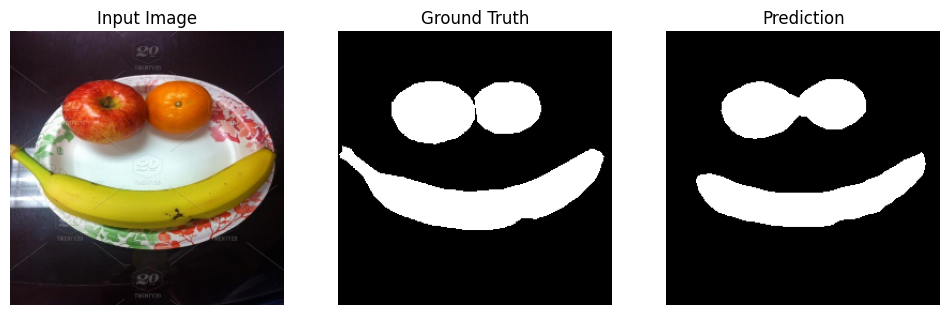

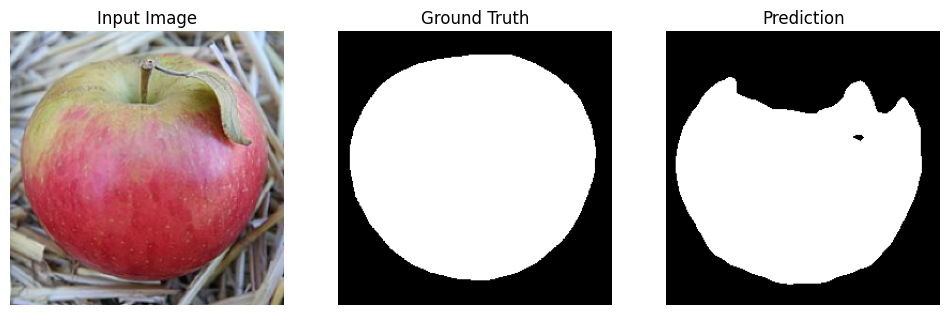

In [ ]:
import matplotlib.pyplot as plt

for i in range(3):

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)

    plt.imshow(images[i].cpu().permute(1,2,0))

    plt.title("Input Image")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(masks[i].squeeze(), cmap="gray")

    plt.title("Ground Truth")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(predictions[i].squeeze(), cmap="gray")

    plt.title("Prediction")

    plt.axis("off")

    plt.show()

In [ ]:
model.load_state_dict(torch.load("pspnet_best.pth", map_location=device))
model.eval()

PSPNet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

def predict_image(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    original = image.copy()

    image = cv2.resize(image, (256,256))

    image = image / 255.0

    image = torch.tensor(
        image.transpose(2,0,1),
        dtype=torch.float32
    )

    image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():

        prediction = model(image)

        prediction = torch.sigmoid(prediction)

        prediction = (prediction > 0.5).float()

    prediction = prediction.squeeze().cpu().numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(prediction, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    segmented = original.copy()

    segmented = cv2.resize(
        segmented,
        (prediction.shape[1], prediction.shape[0])
    )

    segmented[prediction == 0] = 0

    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Segmented Image")
    plt.axis("off")

    plt.show()

Saving Abyssinian_77.jpg to Abyssinian_77.jpg


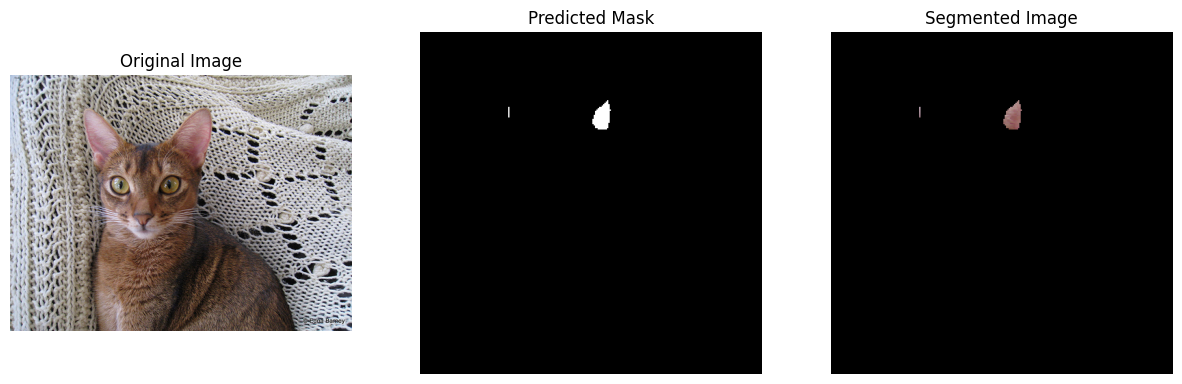

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

predict_image(image_path)

Saving fruit3.jpg to fruit3.jpg


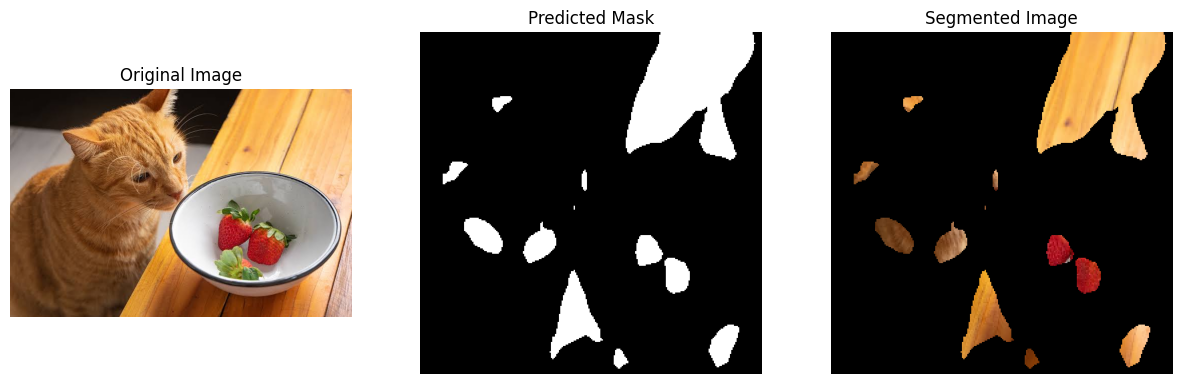

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

predict_image(image_path)

Saving fruit2.jpg to fruit2.jpg


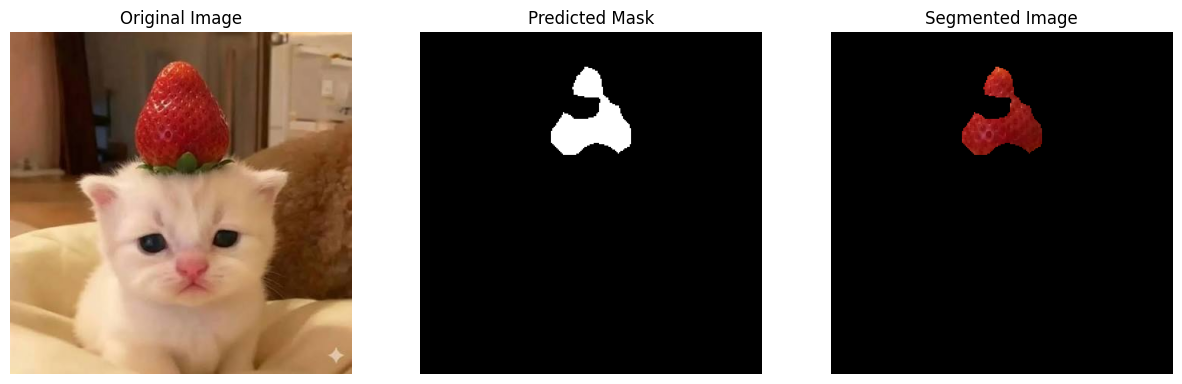

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

predict_image(image_path)

Saving fruit1.jpg to fruit1.jpg


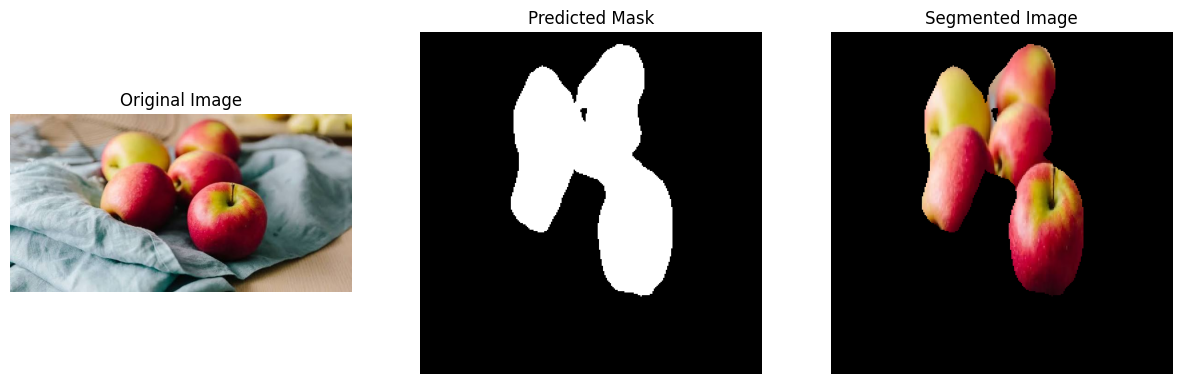

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

predict_image(image_path)